## Convert Air Quality Maps from COG to Zarr

In [1]:
import xarray as xr
import rioxarray
import pandas as pd
import os
from pathlib import Path

In [2]:
def tif_lists(root_dir):   
    fl = os.listdir(root_dir)
    fl.sort()
    fl = [root_dir + '/' + f for f in fl]
    pred_tifs =  list(filter(lambda k: '_state_map_' not in k, fl))
    state_tifs =  list(filter(lambda k: '_state_map_' in k, fl))
    return pred_tifs, state_tifs

# 2. Helper to create a dataset from a list of files
def create_dataset(file_list, name):
    ds = xr.open_mfdataset(
        file_list, 
        combine="nested", 
        concat_dim="time"
    )
    return ds.rename({'band_data': name})

# Chunking strategy:
def make_chunks(ds, delta_t):
    t = ds.dims['time']
    x = ds.dims['x']
    y = ds.dims['y']

    # optimize for time series
    if delta_t == "D" or delta_t == "H":       
        ch = {'time': t, 'x': 20, 'y': 20}

    # optimize for single time step maps
    else:
        ch = {'time': 1, 'x': x, 'y': y}
    return ch

# lookup dict for file naming
temp_step_dict = {
    'H': 'hourly',
    'D': 'daily',
    'M': 'monthly',
    'Y': 'annual',
}

# complete conversion function
def write_zarr(var, method, t_start="2023-01-01", delta_t = "H", res = "100m", version = 'v1'):
    
    name = var.split("_")[0]
    temp = temp_step_dict.get(delta_t)
    
    out_dir = '/home/j/jheisig/R/UseCase_AIRREG/AQ_maps/' + method 
    var_dir = out_dir + '/tifs'
    
    pred_tifs, state_tifs = tif_lists(var_dir)
    
    timestamps = [pd.to_datetime(int(Path(f).stem.split('_')[-1]), unit='s') for f in pred_tifs]
    #timestamps = [pd.to_datetime(int(Path(f).stem.split('_')[-1]), unit='s').tz_localize("UTC") for f in pred_tifs]
    timestamps = pd.to_datetime(timestamps).tz_localize("UTC").tz_convert('CET').tz_localize(None) ##

    ending = "_".join([str(timestamps[-1].date()).replace("-", ""), "4200000-2820000-4280000-2870000", "epsg3035", version])
    out_file = f"{var.lower()}_rf_{temp_step_dict.get(delta_t)}_{res}_s_{t_start.replace('-','')}_{ending}.zarr"
    out_zarr = Path(out_dir, out_file)

    if out_zarr.is_dir():
        print(var, ": completed.")
        
    else:
        print(out_file)

        ds_pred = create_dataset(pred_tifs, "pm2p5_pred").squeeze("band", drop=True)
        ds_state = create_dataset(state_tifs, "pm2p5_smooth").squeeze("band", drop=True)

        # Merge them into one object
        full_dataset = xr.merge([ds_pred, ds_state])

        # Add metadata
        full_dataset.attrs["variable"] = name
        full_dataset.pm2p5_pred.attrs["long_name"] = f"{name} model prediction"
        full_dataset.pm2p5_smooth.attrs["long_name"] = f"{name} exponential smoothing dynamic state"
        full_dataset.attrs["units"] = "ug/m3"
        full_dataset.attrs["temporal aggregation"] = "hourly mean"
        full_dataset.attrs["temporal extent"] = "1 hour (starting at timestemp)"

        # assign timestemps
        full_dataset = full_dataset.assign_coords(time=timestamps)
        #full_dataset.time = full_dataset.time.to_pandas().dt.tz_localize("CET")
        
        # chunks
        full_dataset = full_dataset.chunk(chunks=make_chunks(full_dataset, delta_t))
        
        # write
        full_dataset.to_zarr(out_zarr, mode='w', compute=True)
        
        return full_dataset


### Convert hourly PM2.5 maps

In [3]:
method = "RF_state_smooth_test_noLog_240"
t0 = "2023-01-01"

In [4]:
pm2p5 = write_zarr("PM2p5", method, t_start=t0, delta_t = "H", res = '100m')    
pm2p5

pm2p5_rf_hourly_100m_s_20230101_20230110_4200000-2820000-4280000-2870000_epsg3035_v1.zarr


<xarray.Dataset>
Dimensions:       (x: 800, y: 500, time: 240)
Coordinates:
  * x             (x) float64 4.2e+06 4.2e+06 4.2e+06 ... 4.28e+06 4.28e+06
  * y             (y) float64 2.87e+06 2.87e+06 2.87e+06 ... 2.82e+06 2.82e+06
    spatial_ref   int64 0
  * time          (time) datetime64[ns] 2023-01-01 ... 2023-01-10T23:00:00
Data variables:
    pm2p5_pred    (time, y, x) float32 dask.array<chunksize=(240, 20, 20), meta=np.ndarray>
    pm2p5_smooth  (time, y, x) float32 dask.array<chunksize=(240, 20, 20), meta=np.ndarray>
Attributes:
    variable:              PM2p5
    units:                 ug/m3
    temporal aggregation:  hourly mean
    temporal extent:       1 hour (starting at timestemp)

### Open and check

In [5]:
z = xr.open_dataset("../AQ_maps/RF_state_smooth_test_noLog_240/pm2p5_rf_hourly_100m_s_20230101_20230110_4200000-2820000-4280000-2870000_epsg3035_v1.zarr", engine="zarr")
z

<xarray.Dataset>
Dimensions:       (time: 240, y: 500, x: 800)
Coordinates:
  * time          (time) datetime64[ns] 2023-01-01 ... 2023-01-10T23:00:00
  * x             (x) float64 4.2e+06 4.2e+06 4.2e+06 ... 4.28e+06 4.28e+06
  * y             (y) float64 2.87e+06 2.87e+06 2.87e+06 ... 2.82e+06 2.82e+06
Data variables:
    pm2p5_pred    (time, y, x) float32 ...
    pm2p5_smooth  (time, y, x) float32 ...
    spatial_ref   int64 ...
Attributes:
    temporal aggregation:  hourly mean
    temporal extent:       1 hour (starting at timestemp)
    units:                 ug/m3
    variable:              PM2p5

Chunks were preserved successfully.

In [6]:
z.pm2p5_smooth.encoding

{'chunks': (240, 20, 20),
 'preferred_chunks': {'time': 240, 'y': 20, 'x': 20},
 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0),
 'filters': None,
 '_FillValue': nan,
 'scale_factor': 1.0,
 'add_offset': 0.0,
 'dtype': dtype('float32')}

Hourly timestamps starting at '2023-01-01T00:00:00' (CET).

In [7]:
z.time

<xarray.DataArray 'time' (time: 240)>
array(['2023-01-01T00:00:00.000000000', '2023-01-01T01:00:00.000000000',
       '2023-01-01T02:00:00.000000000', ..., '2023-01-10T21:00:00.000000000',
       '2023-01-10T22:00:00.000000000', '2023-01-10T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-01-01 ... 2023-01-10T23:00:00

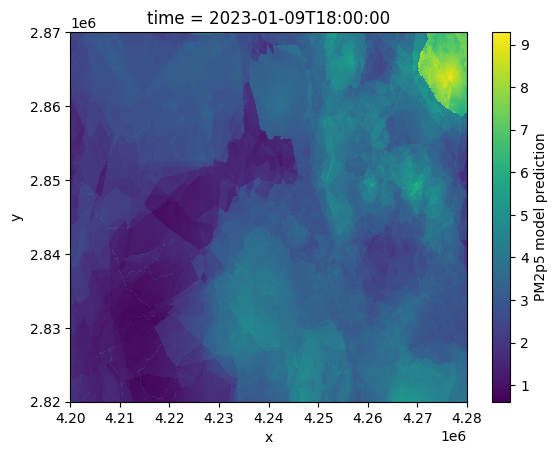

In [8]:
z.pm2p5_pred.isel(time=210).plot()